In [22]:
import os
import sys
import time
import copy

import numpy as np
import math
import random
import matplotlib.pyplot as plt

import functools
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils

import pickle

import datasets, models
import importlib
importlib.reload(models)
import init, measures
importlib.reload(init)
importlib.reload(measures)

<module 'measures' from '/Users/julialand/Desktop/SISSA/RLM/RLM_clean/measures.py'>

In [23]:
from dataclasses import dataclass
@dataclass
class config:

    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers # context length, tuple_size**num_layers for the full input
    beta = 0.8

    train_size = 2**16 #reduce by 9
    batch_size = 128
    accumulation = 1
    test_size = 2**15 #reduce by 6
    seed_sample = 56781234

    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    embedding_dim = 64
    num_heads = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678

    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = False
    loss_threshold = 1e-3
config.num_data = config.train_size + config.test_size
#config.num_data = config.num_classes*config.num_synonyms**((config.tuple_size**config.num_layers-1)//(config.tuple_size-1))
config.input_size = 2**config.num_layers
config.num_batches = config.train_size//config.batch_size
config.max_iters = config.max_epochs*config.num_batches

print(config.device)

print(f"Training for {config.max_iters} steps")

mps
Training for 5120 steps


In [24]:
# reinitialise dataset seeds for multiple runs
config.seed_rules = random.randint(10000000,99999999)
config.seed_sample = random.randint(10000000,99999999)
print(config.seed_rules, config.seed_sample)

19131377 74654505


In [25]:
if config.dataset=='rlm':

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.train_size+config.test_size,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]
    entropy = rlm.entropy

print(inputs.size())
print(targets.size())
train_loader, test_loader = init.init_data(inputs, targets, config)


torch.Size([98304, 2])
torch.Size([98304])


In [26]:
config.num_tokens = 2**config.num_layers
config.seed_model = random.randint(10000000,99999999)

model = init.init_model(config)
model0 = copy.deepcopy( model)

# parameters: 57984


In [27]:
criterion, optimizer, scheduler = init.init_training( model, config)

In [28]:
%%time
dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)
print(dynamics[0])
# print(best)

print_ckpts, save_ckpts = init.init_loglinckpt( config.print_freq, config.max_iters, freq=config.save_freq)
print_ckpt = next(print_ckpts)
save_ckpt = next(save_ckpts)

step = 0
config.outname = f'rlm_L2_v{config.num_features}_beta{config.beta}_mlm_d{config.depth}_ed{config.embedding_dim}_nh{config.num_heads}_{config.seed_rules}'
print(config.outname)

{'t': 0, 'testloss': 4.330078363418579, 'testacc': 0.0152587890625}
rlm_L2_v64_beta0.8_mlm_d1_ed64_nh1_19131377
CPU times: user 119 ms, sys: 28 ms, total: 147 ms
Wall time: 192 ms


In [81]:
for epoch in range(config.max_epochs):

    model.train()
    optimizer.zero_grad()
    running_loss = 0.

    for batch_idx, (inputs, targets) in enumerate(train_loader):

        outputs = model(inputs.to(config.device))
        loss = criterion(outputs, targets.to(config.device))
        running_loss += loss.item()
        loss /= config.accumulation
        loss.backward()

        if ((batch_idx+1)%config.accumulation==0):
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
            step += 1

            if step==print_ckpt:

                test_loss, test_acc = measures.test(model, criterion, test_loader, config.device)

                if test_loss<best['loss']: # update best model if loss is smaller
                    best['step'] = step
                    best['loss'] = test_loss
                    best['model'] = copy.deepcopy( model.state_dict())

                print('step : ',step, '\t running loss: {:06.4f}'.format(running_loss/(batch_idx+1)), ', test loss: {:06.4f}'.format(test_loss))
                print_ckpt = next(print_ckpts)

                if step>=save_ckpt:

                    print(f'Checkpoint at step {step}, saving data ...')
                    save_dict = {'t': step, 'testloss': test_loss, 'testacc': test_acc}
                    if config.measure_train:
                        train_loss, train_acc = measures.test(model, criterion, train_loader, config.device)
                        save_dict['trainloss'] = train_loss
                        save_dict['trainacc'] = train_acc
                    dynamics.append(save_dict)

                    output = {
                        'rules': rlm.M,
                        'init': model0.state_dict(),
                        'best': best,
                        'model': copy.deepcopy(model.state_dict()),
                        'dynamics': dynamics,
                        'step': step
                    }
                    with open(config.outname, "wb") as handle:
                        pickle.dump(config, handle)
                        pickle.dump(output, handle)

                    save_ckpt = next(save_ckpts)


    if (running_loss/(batch_idx+1)) <= config.loss_threshold:

        save_dict = {'t': step, 'testloss': test_loss, 'testacc': test_acc}
        if config.measure_train:
            train_loss, train_acc = measures.test(model, criterion, train_loader, config.device)
            save_dict['trainloss'] = train_loss
            save_dict['trainacc'] = train_acc
        dynamics.append(save_dict)

        output = {
            'rules': rlm.M,
            'init': model0.state_dict(),
            'best': best,
            'model': copy.deepcopy(model.state_dict()),
            'dynamics': dynamics,
            'step': step
        }
        with open(config.outname, "wb") as handle:
            pickle.dump(config, handle)
            pickle.dump(output, handle)

        break

step :  1 	 running loss: 4.2523 , test loss: 4.2786
Checkpoint at step 1, saving data ...
step :  2 	 running loss: 4.2715 , test loss: 4.2771
Checkpoint at step 2, saving data ...
step :  3 	 running loss: 4.2739 , test loss: 4.2738
Checkpoint at step 3, saving data ...
step :  4 	 running loss: 4.2735 , test loss: 4.2692
Checkpoint at step 4, saving data ...
step :  6 	 running loss: 4.2756 , test loss: 4.2562
Checkpoint at step 6, saving data ...
step :  8 	 running loss: 4.2760 , test loss: 4.2399
Checkpoint at step 8, saving data ...
step :  11 	 running loss: 4.2650 , test loss: 4.2168
Checkpoint at step 11, saving data ...
step :  16 	 running loss: 4.2492 , test loss: 4.1942
Checkpoint at step 16, saving data ...
step :  23 	 running loss: 4.2322 , test loss: 4.1815
Checkpoint at step 23, saving data ...
step :  32 	 running loss: 4.2165 , test loss: 4.1767
Checkpoint at step 32, saving data ...
step :  45 	 running loss: 4.2024 , test loss: 4.1721
Checkpoint at step 45, savin

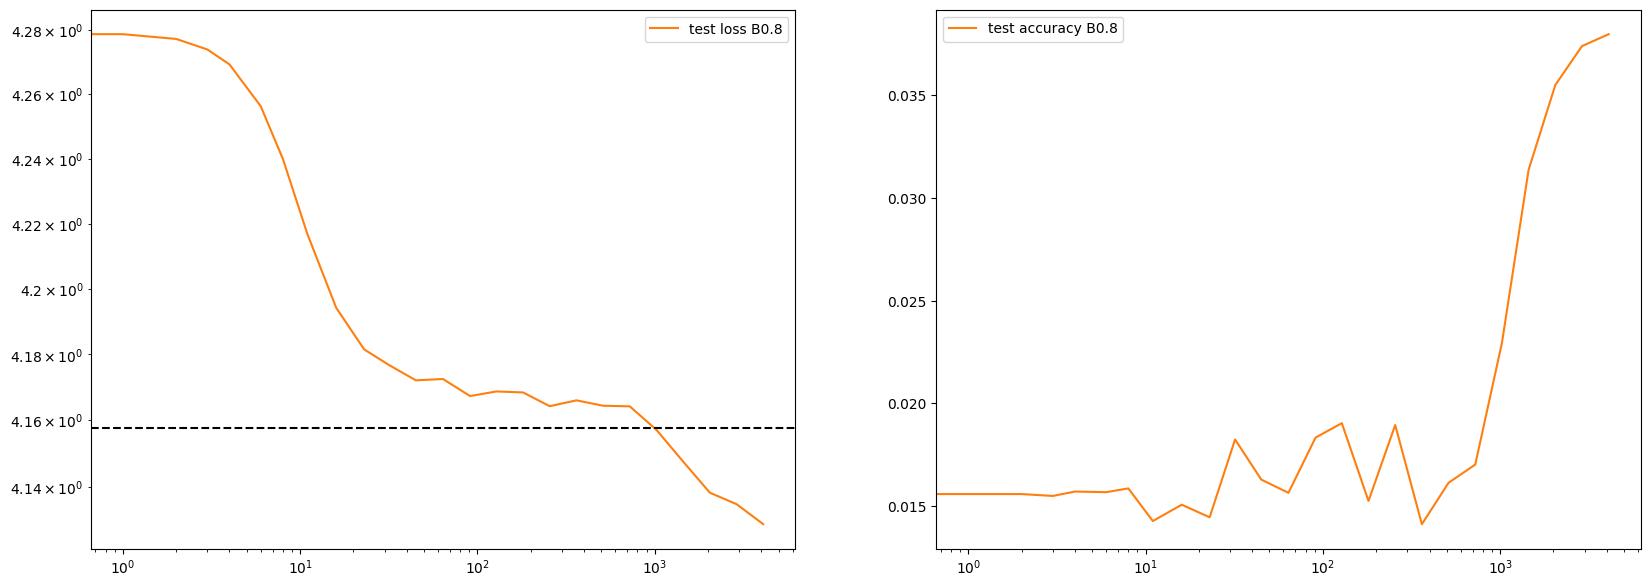

In [82]:
import math
ent_scalar = 4.1576
fig, ax = plt.subplots(1, 2, figsize=(20,7))

ax[0].plot([d['t'] for d in dynamics], [d['testloss'] for d in dynamics], f'C1', label='test loss B' + str(config.beta))
ax[0].axhline(float(ent_scalar), color='k', linestyle='dashed')
ax[1].plot([d['t'] for d in dynamics], [d['testacc'] for d in dynamics], f'C1', label='test accuracy B' + str(config.beta))

if config.measure_train:
    ax[0].plot([d['t'] for d in dynamics], [d['trainloss'] for d in dynamics], f'C0', label='training loss')
    ax[1].plot([d['t'] for d in dynamics], [d['trainacc'] for d in dynamics], f'C0', label='training accuracy')


L = config.num_layers
v = config.num_features



ax[0].legend()
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].legend()
ax[1].set_xscale('log')

## End

In [84]:
import numpy as np 


(array([21., 11.,  9.,  3.,  3.,  2.,  1.,  1.,  2.,  0.,  2.,  0.,  0.,
         0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         2.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([3.06316997e-06, 5.44348404e-05, 1.05806510e-04, 1.57178176e-04,
        2.08549842e-04, 2.59921537e-04, 3.11293203e-04, 3.62664869e-04,
        4.14036534e-04, 4.65408200e-04, 5.16779895e-04, 5.68151532e-04,
        6.19523227e-04, 6.70894864e-04, 7.22266559e-04, 7.73638196e-04,
        8.25009891e-04, 8.76381586e-04, 9.27753223e-04, 9.79124918e-04,
        1.03049655e-03, 1.08186819e-03, 1.13323983e-03, 1.18461146e-03,
        1.23598322e-03, 1.28735485e-03, 1.33872649e-03, 1.39009824e-03,
        1.44146988e-03, 1.49284152e-03, 1.54421316e-03, 1.59558491e-03,
        1.64695655e-03, 1.69832818e-03, 1.74969994e-03, 1.80107157e-03,
        1.85244321e-03, 1.90381485e-03, 1.95518672e-03, 2.00655824e-

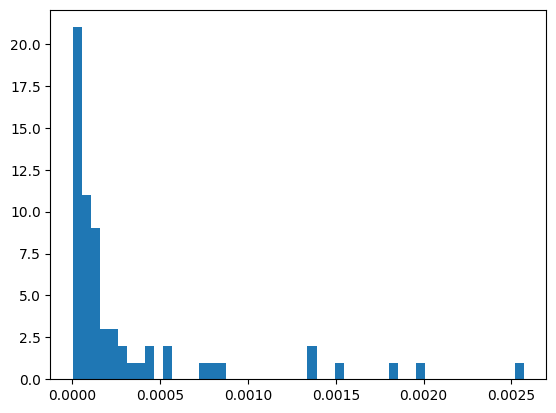

In [88]:
a =rlm.M[0,0,:].numpy()
plt.hist(a, bins=50)


# Diference theorical - Experimental

In [29]:
prior = labels = torch.randint(config.num_features, (config.num_features,))

In [30]:
print(f"For beta: {config.beta} & for Vocabulary: {config.num_features}")
print(f"Theoretical: {init.measures.conditional_entropy_from_joint(init.measures.joint_children(rlm.M, prior)).item()}")
print(f"Experimental: {test_loss}")
print(f"Difference: {init.measures.conditional_entropy_from_joint(init.measures.joint_children(rlm.M, prior)).item() - test_loss}")

For beta: 0.8 & for Vocabulary: 64


AttributeError: module 'measures' has no attribute 'conditional_entropy_from_joint'

In [31]:
prior = labels = torch.randint(config.num_features, (config.num_features,))
#init.measures.conditional_entropy(rlm.M,)